# market prediction

## simulated market

annual growth ~ 7 % -> daily growth 0.4 %

In [17]:
import numpy as np
import matplotlib.pyplot as plt

[0.04653343 0.01196818 0.09510779 0.00466303 0.04044209 0.17727469
 0.15241852 0.17049711 0.05043816 0.03939049 0.13905343 0.14652982
 0.02572929 0.04849997 0.01110452 0.15179169 0.11299893 0.06088293
 0.12062653 0.06095537 0.15701879 0.10631485 0.13323723 0.15247669
 0.17353506 0.1703258  0.11069204 0.11187424 0.0458585  0.09384002
 0.14545471 0.07913161 0.12805837 0.12763887 0.17546804 0.17839179
 0.05226447 0.19990212 0.14281502 0.02427772 0.03804987 0.13929422
 0.15067185 0.00861686 0.10763578 0.08557134 0.13077419 0.0900384
 0.02551975 0.08153673]
expected average return is 1.0592192797944429


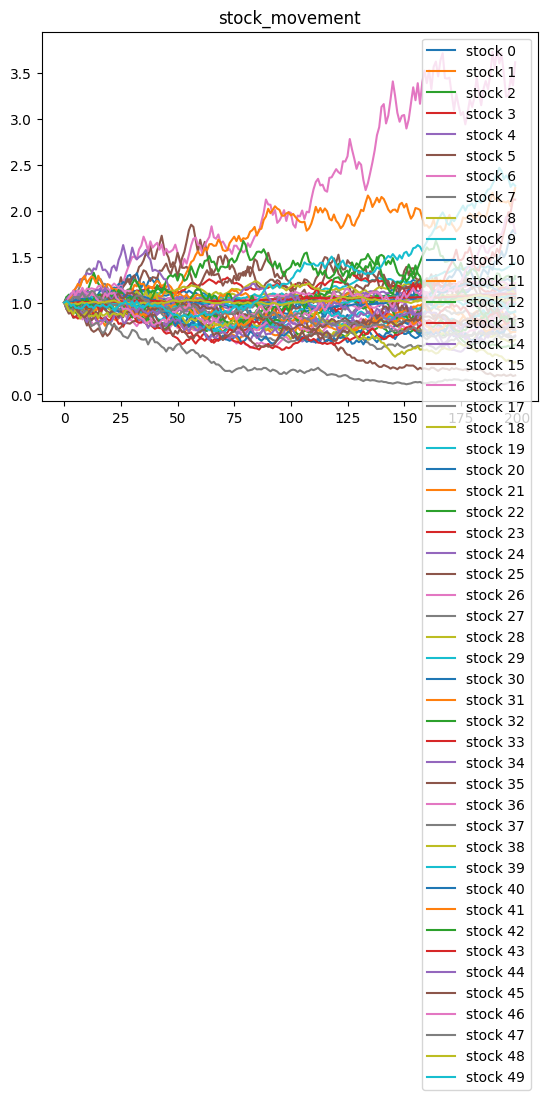

In [55]:
time_points = 200
number_stocks = 50
fluctuation_range = 0.2 * np.random.random(number_stocks)
print(fluctuation_range)
# exponent_end = 2.
# interval = exponent_end / time_points

new_market_data = np.ones((number_stocks, time_points))
time_point_fluctuation = np.random.random((number_stocks, time_points)) 
for i in range(new_market_data.shape[1] -1):
    new_market_data[:, i+1] *= (1.0004 - fluctuation_range/2 + time_point_fluctuation[:, i] * fluctuation_range) * new_market_data[:, i]

print(f"expected average return is {np.mean(new_market_data[:, -1])}")

for i in range(new_market_data.shape[0]):
    plt.plot(new_market_data[i,:], label=f"stock {i}")
plt.title("stock_movement")
plt.legend()
plt.show()

## use MLP to predict next stock moves

assuming Markov property from previous date, predict the next-day stock values

In [2]:
from models import MLP_predictor
import torch
    
from torchinfo import summary
model = MLP_predictor(3)
print(summary(model, (4, 3)))
# print(model((3, 2, 2)))

Layer (type:depth-idx)                        Output Shape              Param #
MLP_predictor                                 [4, 3]                    --
├─ModuleList: 1-1                             --                        --
│    └─ParametrizedLinear: 2-1                [4, 256]                  256
│    │    └─ModuleDict: 3-1                   --                        1,024
│    └─Tanh: 2-2                              [4, 256]                  --
│    └─ParametrizedLinear: 2-3                [4, 256]                  256
│    │    └─ModuleDict: 3-2                   --                        65,792
│    └─Tanh: 2-4                              [4, 256]                  --
│    └─ParametrizedLinear: 2-5                [4, 256]                  256
│    │    └─ModuleDict: 3-3                   --                        65,792
│    └─Tanh: 2-6                              [4, 256]                  --
│    └─ParametrizedLinear: 2-7                [4, 3]                    3
│    │ 

In [471]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
# device = "cpu"
loss_fn = torch.nn.MSELoss()

epochs = 100

model = MLP_predictor(number_stocks)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_proportion = 0.8
train_idx = int(time_points * train_proportion)

train_data = torch.tensor(new_market_data[:, :train_idx].astype(np.float32)).transpose(1, 0).to(device)
unseen_market_data = torch.tensor(new_market_data[:, train_idx:].astype(np.float32)).transpose(1, 0).to(device)

prev_test_loss = np.inf
conseq_no_improvement = 0

for i in range(epochs):

    model.train()
    optimizer.zero_grad()
    prediction = model(train_data)[:-1, :]
    loss = loss_fn(prediction, train_data[1:, :])
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f"train loss for epoch {i} = {loss.detach().cpu().numpy()}")

    model.eval()
    prediction = model(unseen_market_data)[:-1, :]
    loss = loss_fn(prediction, unseen_market_data[1:, :])
    test_loss = loss.detach().cpu().numpy()
    print(f"test loss for epoch {i} = {test_loss}")
    # if test_loss < prev_test_loss:
    #     prev_test_loss = test_loss
    #     conseq_no_improvement = 0
    #     print("prev_test_loss improved")
    # else:
    #     conseq_no_improvement += 1
    #     if conseq_no_improvement >= 5:
    #         break



NameError: name 'time_points' is not defined

In [75]:
torch.save(model.state_dict(), "predict_market.pt")

expected average return is 1.1224116779947912
test loss for unseen market data = 0.20069751143455505


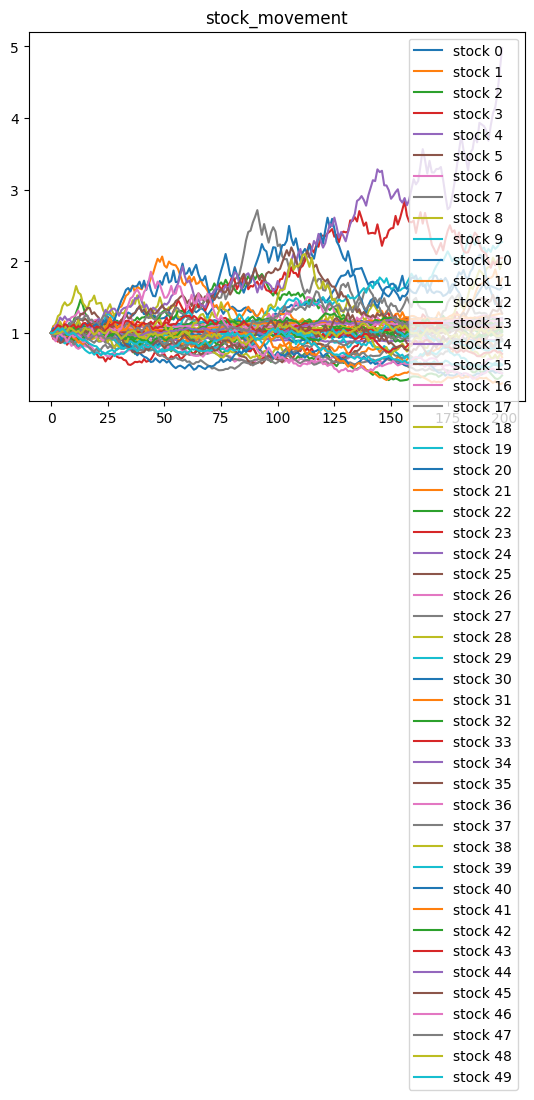

In [74]:
# evaluate on new simulated market data

time_points = 200
number_stocks = 50
fluctuation_range = 0.2 * np.random.random(number_stocks)
# print(fluctuation_range)
# exponent_end = 2.
# interval = exponent_end / time_points

new_market_data = np.ones((number_stocks, time_points))
time_point_fluctuation = np.random.random((number_stocks, time_points)) 
for i in range(new_market_data.shape[1] -1):
    new_market_data[:, i+1] *= (1.0004 - fluctuation_range/2 + time_point_fluctuation[:, i] * fluctuation_range) * new_market_data[:, i]

print(f"expected average return is {np.mean(new_market_data[:, -1])}")




unseen_market_data = torch.tensor(new_market_data.astype(np.float32)).transpose(1, 0).to(device)


model.eval()
prediction = model(unseen_market_data)[:-1, :]
loss = loss_fn(prediction, unseen_market_data[1:, :])
test_loss = loss.detach().cpu().numpy()
print(f"test loss for unseen market data = {test_loss}")

for i in range(new_market_data.shape[0]):
    plt.plot(new_market_data[i,:], label=f"stock {i}")
plt.title("stock_movement")
plt.legend()
plt.show()

## Real market

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
class StockDataset(Dataset):
    def __init__(self, numpy_array, time_window=5):
        super().__init__()
        self.data = numpy_array
        self.time_window = time_window
        assert self.data.shape[-1] > time_window, f"time_window ({time_window}) is too big compared to available data of length {self.data.shape[-1]}"
    
    def __len__(self):
        return self.data.shape[-1] - self.time_window
    
    def __getitem__(self, idx):
        return self.data[:, idx: idx+self.time_window], self.data[:, idx+self.time_window]
    

In [2]:
from data_utils import get_csv_list, batch_load
folder = "./data"
print(get_csv_list(folder))
print(batch_load(
    get_csv_list(folder), 
    pd_df=True, 
    normalise=True
    )
    # .to_numpy().transpose().shape
    )

['./data/v.csv', './data/bac.csv', './data/amc.csv', './data/intc.csv', './data/nvda.csv', './data/jpm.csv', './data/googl.csv', './data/jd.csv', './data/sp500.csv', './data/bmy.csv']
             v       bac       amc      intc        nvda       jpm     googl  \
0     6.771810  2.951734  0.012244  0.846242  265.152174  4.853240  5.704093   
1     6.840762  2.944935  0.012422  0.808852  255.108696  4.698172  5.583846   
2     6.701524  2.836846  0.012155  0.801602  257.065217  4.644083  5.613908   
3     6.704762  2.806934  0.011977  0.761923  245.760870  4.612332  5.942774   
4     6.641905  2.789939  0.011977  0.760015  242.347826  4.615101  5.873597   
...        ...       ...       ...       ...         ...       ...       ...   
2755  1.028000  1.027872  1.010686  1.026707    1.021739  1.029167  1.038392   
2756  1.019048  1.027872  1.024043  1.018695    1.021739  1.016984  1.040565   
2757  1.021524  1.038069  1.032057  1.004578    1.021739  1.010707  1.028251   
2758  1.014286  

In [31]:
from data_utils import get_csv_list, batch_load
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


market_df = batch_load(
    get_csv_list("./data"), 
    pd_df=True, 
    # normalise=True,
)
stock_names = market_df.columns
sp500_idx = stock_names.get_loc("sp500")
print(stock_names)
market_database = market_df.to_numpy().transpose()
print(market_database)


Index(['v', 'bac', 'amc', 'intc', 'nvda', 'jpm', 'googl', 'jd', 'sp500',
       'bmy'],
      dtype='object')
[[3.55520e+02 3.59140e+02 3.51830e+02 ... 5.36300e+01 5.32500e+01
  5.25000e+01]
 [4.34200e+01 4.33200e+01 4.17300e+01 ... 1.52700e+01 1.50000e+01
  1.47100e+01]
 [2.75000e+00 2.79000e+00 2.73000e+00 ... 2.31800e+02 2.31100e+02
  2.24600e+02]
 ...
 [3.59000e+01 3.41000e+01 3.40900e+01 ... 2.02800e+01 2.12500e+01
  2.17500e+01]
 [5.80720e+03 5.67965e+03 5.66360e+03 ... 1.90201e+03 1.89332e+03
  1.88819e+03]
 [4.73000e+01 4.62000e+01 4.69000e+01 ... 4.88900e+01 4.88900e+01
  4.88200e+01]]


(10, 2760)
average return = 29.19865132347046
sp500 return = 3.075537949041145
best stock performance = 265.15217391304344
final yield for perfect knowledge performance with chance 0.3 = 433132857.936105


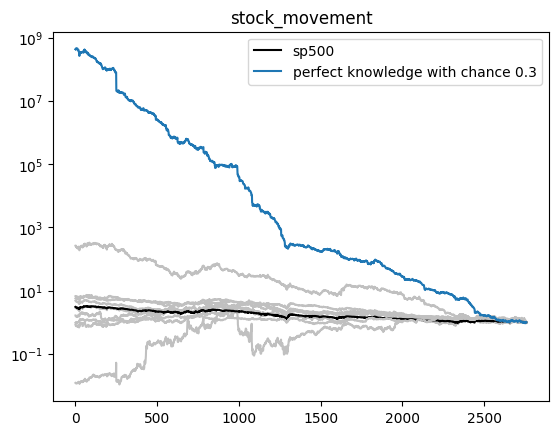

In [13]:

optimal_chance = 0.3
transaction_cost = 0.5
total_time_points = -1

if total_time_points >= 1:
    market_database = market_database[:, :total_time_points]
print(market_database.shape)
norm_market_database = np.zeros_like(market_database)
for i in range(market_database.shape[0]):
    norm_market_database[i, :] = market_database[i, :] / market_database[i, -1]
delta = norm_market_database[:, :-1] / norm_market_database[:, 1:]
optimal_performance = np.ones(norm_market_database.shape[-1])

for i in range(norm_market_database.shape[1]-1, 0, -1):
    if np.random.random() < optimal_chance:
        optimal_performance[i-1] = (np.max(delta[:, i-1]) - transaction_cost/100) * optimal_performance[i]
    else:
        optimal_performance[i-1] = (np.random.choice(delta[:, i-1]) - transaction_cost/100) * optimal_performance[i]

# print(f"overall market trend = {overall_market_trend}")
print(f"average return = {np.mean(norm_market_database[:, 0])}")
print(f"sp500 return = {norm_market_database[sp500_idx, 0]}")
print(f"best stock performance = {np.max(norm_market_database[:, 0])}")
print(f"final yield for perfect knowledge performance with chance {optimal_chance} = {optimal_performance[0]}")

for i in range(norm_market_database.shape[0]):
    if i != sp500_idx:
        plt.plot(
            norm_market_database[i,:],
            color="#c0c0c0"
        )
    else:
        plt.plot(
            norm_market_database[i,:],
            label = "sp500",
            color="#000000"
        )
plt.plot(optimal_performance, label=f"perfect knowledge with chance {optimal_chance}")
plt.title("stock_movement")
plt.yscale("log")
plt.legend()
plt.show()

In [43]:
from models import MLP_predictor

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


def prepare_training_data(market_database, print_log=True):
    new_market_data = np.flip(market_database, axis=-1)

    daily_changes = np.ones((new_market_data.shape[0], new_market_data.shape[1]-1))
    for i in range(new_market_data.shape[0]):
        daily_changes[i, :] = new_market_data[i, 1:] / new_market_data[i, :-1]
   
    train_proportion = 0.8
    train_idx = int(daily_changes.shape[-1] * train_proportion)

    if print_log:
        print(new_market_data)
        print(daily_changes)

    train_data = torch.tensor(daily_changes[:, :train_idx].astype(np.float32)).transpose(1, 0).to(device)
    unseen_market_data = torch.tensor(daily_changes[:, train_idx:].astype(np.float32)).transpose(1, 0).to(device)

    return train_data, unseen_market_data

def train(train_data, unseen_market_data, print_log=True):

    # device = "cpu"
    loss_fn = torch.nn.MSELoss()
    ce_loss = torch.nn.CrossEntropyLoss()

    number_stocks = train_data.shape[1]
    epochs = 100

    model = MLP_predictor(number_stocks)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for i in range(epochs):

        model.train()
        optimizer.zero_grad()
        prediction = model(train_data)[:-1, :]
        loss = loss_fn(prediction, train_data[1:, :])
        # loss = ce_loss(prediction, train_data[1:, :].argmax(dim=1))
        loss.backward()
        optimizer.step()
        scheduler.step()
        if print_log:
            print(f"train loss for epoch {i} = {loss.detach().cpu().numpy()}")

        model.eval()
        prediction = model(unseen_market_data)[:-1, :]
        loss = loss_fn(prediction, unseen_market_data[1:, :])
        # loss = ce_loss(prediction, unseen_market_data[1:, :].argmax(dim=1))
        test_loss = loss.detach().cpu().numpy()
        if print_log:
            print(f"test loss for epoch {i} = {test_loss}")
        # if test_loss < prev_test_loss:
        #     prev_test_loss = test_loss
        #     conseq_no_improvement = 0
        #     print("prev_test_loss improved")
        # else:
        #     conseq_no_improvement += 1
        #     if conseq_no_improvement >= 5:
        #         break
    return model

train_set, test_set = prepare_training_data(market_database)
model = train(train_set, test_set)

[[5.25000e+01 5.32500e+01 5.36300e+01 ... 3.51830e+02 3.59140e+02
  3.55520e+02]
 [1.47100e+01 1.50000e+01 1.52700e+01 ... 4.17300e+01 4.33200e+01
  4.34200e+01]
 [2.24600e+02 2.31100e+02 2.31800e+02 ... 2.73000e+00 2.79000e+00
  2.75000e+00]
 ...
 [2.17500e+01 2.12500e+01 2.02800e+01 ... 3.40900e+01 3.41000e+01
  3.59000e+01]
 [1.88819e+03 1.89332e+03 1.90201e+03 ... 5.66360e+03 5.67965e+03
  5.80720e+03]
 [4.88200e+01 4.88900e+01 4.88900e+01 ... 4.69000e+01 4.62000e+01
  4.73000e+01]]
[[1.01428571 1.00713615 0.99757598 ... 0.99951705 1.02077708 0.98992037]
 [1.01971448 1.018      0.99017682 ... 1.01065633 1.03810208 1.0023084 ]
 [1.02894034 1.00302899 0.99223469 ... 1.01486989 1.02197802 0.98566308]
 ...
 [0.97701149 0.95435294 1.13313609 ... 1.01458333 1.00029334 1.05278592]
 [1.00271689 1.00458982 1.00513141 ... 1.00880271 1.00283389 1.02245737]
 [1.00143384 1.         1.00736347 ... 0.99787234 0.98507463 1.02380952]]
train loss for epoch 0 = 1.0481984615325928
test loss for epoch 

In [72]:
torch.save(model.state_dict(), "predict_real_market.pt")

In [15]:
model.eval()
prediction = model(test_set)
pred = prediction.detach().cpu().numpy()
pred = np.argmax(pred, axis=-1)
print(pred)
truth = test_set.detach().cpu().numpy()
truth = np.argmax(truth, axis=-1)
print(truth)



[0 2 5 5 0 2 5 2 8 7 5 5 5 8 4 0 0 8 5 4 5 5 5 7 5 1 8 8 5 2 8 5 4 5 4 5 5
 0 1 0 4 5 4 7 1 8 5 5 8 5 0 0 8 5 5 5 5 5 5 2 7 4 5 2 5 5 5 0 5 5 5 5 5 5
 5 5 2 7 2 8 5 5 5 8 5 5 0 1 5 4 5 5 5 5 8 5 5 4 1 2 0 5 5 5 5 2 2 1 5 5 2
 5 2 7 1 5 2 1 2 7 7 2 7 2 5 5 5 7 5 2 7 2 5 5 5 1 7 5 2 5 0 2 5 2 5 7 5 5
 5 5 5 5 5 5 5 5 5 2 2 5 2 5 2 2 5 4 4 5 5 8 5 5 5 5 5 7 5 2 5 5 5 2 5 5 5
 5 5 5 5 5 7 4 4 2 5 1 5 5 5 8 5 6 5 5 5 2 5 5 5 5 5 8 2 7 5 5 7 5 0 5 7 4
 5 8 5 6 5 5 4 8 8 4 5 4 7 5 2 5 8 5 1 5 5 5 2 1 7 4 5 4 2 5 5 7 4 0 5 7 1
 5 5 0 1 5 2 5 5 2 4 5 2 5 7 2 4 5 2 5 0 1 7 7 0 1 5 2 8 1 5 7 1 3 7 4 1 5
 5 5 5 2 5 5 1 7 7 7 5 1 5 5 7 4 7 7 7 1 7 8 5 5 2 5 5 5 4 5 5 5 4 2 5 2 5
 5 5 5 4 5 5 5 5 7 5 1 5 8 5 0 2 0 5 2 1 4 5 0 5 7 2 1 7 7 1 5 5 4 5 5 5 5
 5 2 5 4 5 0 5 2 5 2 1 0 5 4 5 5 5 5 5 5 0 5 0 5 0 7 5 0 0 5 6 4 5 0 4 5 5
 8 5 5 2 5 5 5 5 0 4 5 5 6 8 4 5 5 8 5 5 8 5 2 4 5 4 6 8 5 5 4 5 5 0 5 5 0
 4 5 4 6 0 2 5 5 2 1 7 2 4 5 5 5 5 2 5 5 5 5 0 2 2 2 7 5 5 5 5 5 8 5 2 0 7
 2 5 2 5 4 5 5 5 5 5 5 5 

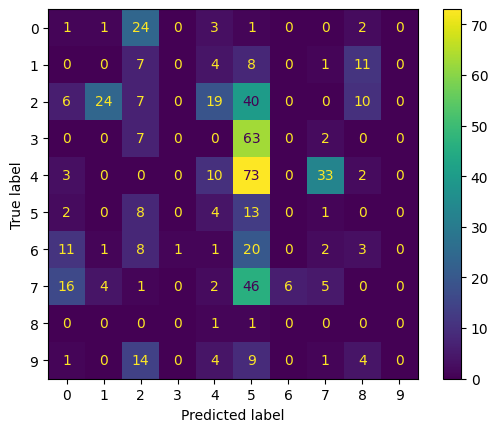

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(truth, pred)

In [27]:
prediction_performance = np.ones_like(pred).astype(np.float32)
perfect_performance = np.ones_like(pred).astype(np.float32)

real_data = np.flip(norm_market_database, axis=-1)[:, train_idx:]
delta = real_data[:, 1:] / real_data[:, :-1]

print(real_data)

for i in range(prediction_performance.shape[0] -1):
    prediction_performance[i+1] = delta[pred[i], i] * prediction_performance[i]
    perfect_performance[i+1] = delta[truth[i], i] * perfect_performance[i]


for i in range(real_data.shape[0]):
    if i == sp500_idx:
        plt.plot(
            real_data[i,:],
            label = "sp500",
            color="#000000"
        )
    else:
        plt.plot(
            real_data[i,:],
            color="#c0c0c0"
        )
# plt.plot(perfect_performance, label=f"perfect knowledge")
plt.plot(prediction_performance, label="prediction performance")
plt.title("stock_movement")
plt.yscale("log")
plt.legend()
plt.show()

NameError: name 'norm_market_database' is not defined

In [17]:
def evaluate(model, unseen_market_data, print_log=True):
    model.eval()
    prediction = model(unseen_market_data)
    pred = prediction.detach().cpu().numpy()
    pred = np.argmax(pred, axis=-1)
    
    truth = unseen_market_data.detach().cpu().numpy()
    truth = np.argmax(truth, axis=-1)
    if print_log:
        print(pred)
        print(truth)
    return pred, truth
    

def calculate_performance(pred, truth, real_data, print_log=True):
    prediction_performance = np.ones_like(pred).astype(np.float32)
    perfect_performance = np.ones_like(pred).astype(np.float32)

    delta = real_data[1:, :] / real_data[:-1, :]
    if print_log:
        print(real_data)

    for i in range(delta.shape[0] -1, -1, -1):
        prediction_performance[i] = delta[i, pred[i]] * prediction_performance[i+1]
        perfect_performance[i] = delta[i, pred[i]] * perfect_performance[i+1]

    return prediction_performance

norm_market_database = np.zeros_like(market_database)
for i in range(market_database.shape[0]):
    norm_market_database[i, :] = market_database[i, :] / market_database[i, -1]

pred, truth = evaluate(model, test_set)
calculate_performance(pred, truth, test_set)


[0 2 5 5 0 2 5 2 8 7 5 5 5 8 4 0 0 8 5 4 5 5 5 7 5 1 8 8 5 2 8 5 4 5 4 5 5
 0 1 0 4 5 4 7 1 8 5 5 8 5 0 0 8 5 5 5 5 5 5 2 7 4 5 2 5 5 5 0 5 5 5 5 5 5
 5 5 2 7 2 8 5 5 5 8 5 5 0 1 5 4 5 5 5 5 8 5 5 4 1 2 0 5 5 5 5 2 2 1 5 5 2
 5 2 7 1 5 2 1 2 7 7 2 7 2 5 5 5 7 5 2 7 2 5 5 5 1 7 5 2 5 0 2 5 2 5 7 5 5
 5 5 5 5 5 5 5 5 5 2 2 5 2 5 2 2 5 4 4 5 5 8 5 5 5 5 5 7 5 2 5 5 5 2 5 5 5
 5 5 5 5 5 7 4 4 2 5 1 5 5 5 8 5 6 5 5 5 2 5 5 5 5 5 8 2 7 5 5 7 5 0 5 7 4
 5 8 5 6 5 5 4 8 8 4 5 4 7 5 2 5 8 5 1 5 5 5 2 1 7 4 5 4 2 5 5 7 4 0 5 7 1
 5 5 0 1 5 2 5 5 2 4 5 2 5 7 2 4 5 2 5 0 1 7 7 0 1 5 2 8 1 5 7 1 3 7 4 1 5
 5 5 5 2 5 5 1 7 7 7 5 1 5 5 7 4 7 7 7 1 7 8 5 5 2 5 5 5 4 5 5 5 4 2 5 2 5
 5 5 5 4 5 5 5 5 7 5 1 5 8 5 0 2 0 5 2 1 4 5 0 5 7 2 1 7 7 1 5 5 4 5 5 5 5
 5 2 5 4 5 0 5 2 5 2 1 0 5 4 5 5 5 5 5 5 0 5 0 5 0 7 5 0 0 5 6 4 5 0 4 5 5
 8 5 5 2 5 5 5 5 0 4 5 5 6 8 4 5 5 8 5 5 8 5 2 4 5 4 6 8 5 5 4 5 5 0 5 5 0
 4 5 4 6 0 2 5 5 2 1 7 2 4 5 5 5 5 2 5 5 5 5 0 2 2 2 7 5 5 5 5 5 8 5 2 0 7
 2 5 2 5 4 5 5 5 5 5 5 5 

array([2.5982425 , 2.5525932 , 2.3897614 , 2.3455074 , 2.4014378 ,
       2.3566542 , 2.3121068 , 2.42992   , 2.360122  , 2.2783003 ,
       2.3305004 , 2.3087752 , 2.2499201 , 2.2811215 , 2.2242002 ,
       2.2530499 , 2.2298636 , 2.212936  , 2.177589  , 2.1649122 ,
       2.1032383 , 2.1284063 , 2.1307073 , 2.1218612 , 2.1209471 ,
       2.1927497 , 2.2014773 , 2.192124  , 2.180905  , 2.196175  ,
       2.0444658 , 2.014029  , 2.046242  , 1.9801041 , 1.9711413 ,
       1.9370222 , 1.9212523 , 1.9090815 , 1.9140044 , 1.8848896 ,
       1.8642653 , 1.8981411 , 1.82959   , 1.8157892 , 1.8266548 ,
       1.7864411 , 1.7682923 , 1.7740314 , 1.8082001 , 1.7941574 ,
       1.860608  , 1.8772414 , 1.859667  , 1.85374   , 1.864114  ,
       1.8381137 , 1.8498337 , 1.8541201 , 1.9172156 , 1.8997272 ,
       1.944113  , 1.8978596 , 1.7422118 , 1.7519403 , 1.6804513 ,
       1.6413217 , 1.6712838 , 1.6951716 , 1.7118937 , 1.7089177 ,
       1.7265607 , 1.7138411 , 1.729868  , 1.6922764 , 1.75216

In [40]:
import matplotlib.pyplot as plt

train_number = 10
predictions = []
raw_results = []
train_set, test_set = prepare_training_data(market_database)
models = []

for i in range(train_number):
    
    
    model = train(train_set, test_set, print_log=False)
    models.append(model)
    pred, truth = evaluate(model, test_set, print_log=False)
    predictions.append(pred)
    raw_results.append(calculate_performance(pred, truth, test_set, print_log=False))



[[5.25000e+01 5.32500e+01 5.36300e+01 ... 3.51830e+02 3.59140e+02
  3.55520e+02]
 [1.47100e+01 1.50000e+01 1.52700e+01 ... 4.17300e+01 4.33200e+01
  4.34200e+01]
 [2.24600e+02 2.31100e+02 2.31800e+02 ... 2.73000e+00 2.79000e+00
  2.75000e+00]
 ...
 [2.17500e+01 2.12500e+01 2.02800e+01 ... 3.40900e+01 3.41000e+01
  3.59000e+01]
 [1.88819e+03 1.89332e+03 1.90201e+03 ... 5.66360e+03 5.67965e+03
  5.80720e+03]
 [4.88200e+01 4.88900e+01 4.88900e+01 ... 4.69000e+01 4.62000e+01
  4.73000e+01]]
[[1.01428571 1.00713615 0.99757598 ... 0.99951705 1.02077708 0.98992037]
 [1.01971448 1.018      0.99017682 ... 1.01065633 1.03810208 1.0023084 ]
 [1.02894034 1.00302899 0.99223469 ... 1.01486989 1.02197802 0.98566308]
 ...
 [0.97701149 0.95435294 1.13313609 ... 1.01458333 1.00029334 1.05278592]
 [1.00271689 1.00458982 1.00513141 ... 1.00880271 1.00283389 1.02245737]
 [1.00143384 1.         1.00736347 ... 0.99787234 0.98507463 1.02380952]]


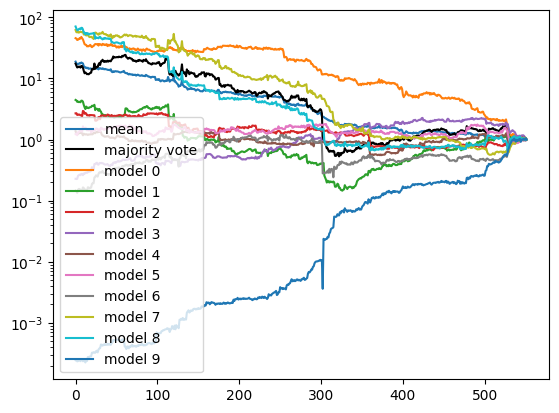

In [41]:
predictions = np.stack(predictions, axis=0)
raw_results = np.stack(raw_results, axis=0)

mean = np.mean(raw_results, axis=0)
# std = np.std(raw_results, axis=0)
# upper_line = mean+std
# lower_line = mean-std

import scipy as sp
majority_vote = sp.stats.mode(predictions)
# print(majority_vote[0])

maj_vote_results = calculate_performance(majority_vote[0], truth, test_set, print_log=False)

plt.plot(mean, label="mean")
# plt.plot(upper_line, label="mean+std")
# plt.plot(lower_line, label="mean-std")
plt.plot(maj_vote_results, label="majority vote", color="#000000")
for i in range(raw_results.shape[0]):
    plt.plot(
        raw_results[i, :], 
        # color="#c0c0c0"
        label=f"model {i}"
    )
plt.legend()
plt.yscale("log")
# plt.ylim((0.1, 10))
# plt.xlim((0, 200))
plt.show()

In [34]:
import os
def save_models(models, folder, model_indices):
    for idx in model_indices:
        torch.save(models[idx].state_dict(), os.path.join(folder, f"model_{idx}.pt"))

save_models(models, "./results/202505142113", [3, 4])

## use models for prediction

In [42]:
from models import load_models
import torch

models = load_models("./results/202505142113", 10)

stocks = ['v', 'bac', 'amc', 'intc', 'nvda', 'jpm', 'googl', 'jd', 'sp500', 'bmy']

stock_today = torch.tensor([355.6, 44.20, 2.7598, 22.53, 133.80, 262.88, 160.2, 36.62, 5920, 46.98])
stock_yesterday = torch.tensor([356.14, 44.28, 2.7400, 22.56, 129.93, 263.01, 159.53, 37.25, 5886.55, 46.59])

change = stock_today / stock_yesterday

for model in models:
    prediction = model(change).detach()
    print(prediction)
    print(stocks[torch.argmax(prediction)])

tensor([1.0009, 1.0007, 1.0044, 1.0009, 1.0029, 1.0005, 1.0011, 1.0007, 1.0006,
        1.0003])
amc
tensor([1.0004, 1.0004, 1.0030, 1.0012, 1.0022, 1.0005, 1.0008, 1.0004, 0.9999,
        0.9993])
amc


In [ ]:
# check model weights
for model in models:
    for i in [2, 4, 6]:
        print(model.layers[i].weight)

tensor([[-0.0757,  0.0136,  0.0223,  ...,  0.0114,  0.0198, -0.0332],
        [ 0.0023, -0.0312,  0.0418,  ..., -0.0681, -0.0300, -0.0648],
        [ 0.0397,  0.0356,  0.0428,  ...,  0.0375, -0.0601, -0.0453],
        ...,
        [-0.0667, -0.0429, -0.0156,  ...,  0.0640,  0.0223, -0.0165],
        [-0.0235, -0.0093,  0.0350,  ..., -0.0041, -0.0176,  0.0321],
        [ 0.0352, -0.0226, -0.0434,  ..., -0.0059,  0.0138, -0.0355]],
       grad_fn=<WeightNormInterfaceBackward0>)
tensor([[-0.0391,  0.0408, -0.0006,  ...,  0.0034, -0.0422, -0.0342],
        [ 0.0459, -0.0160, -0.0204,  ..., -0.0593,  0.0082,  0.0024],
        [-0.0394,  0.0286,  0.0652,  ..., -0.0481,  0.0433,  0.0086],
        ...,
        [ 0.0013, -0.0133,  0.0418,  ..., -0.0457,  0.0036, -0.0361],
        [ 0.0404, -0.0567,  0.0144,  ..., -0.0378, -0.0253,  0.0063],
        [ 0.0182,  0.0237, -0.0454,  ...,  0.0342, -0.0287,  0.0192]],
       grad_fn=<WeightNormInterfaceBackward0>)
tensor([[-1.5502e-02, -4.4786e-02, -1.